# **1. Identificação e descrição do problema**

*   Título: Predição do risco de vício em jogos

*   Integrantes: Gabriel Rocha Valentim Bastos e Luis Roberto Santana Santos

*   Fonte dos dados: https://www.kaggle.com/datasets/shaistashahid/gaming-and-mental-health?resource=download

*   Objetivo: Prever a propensão de uma pessoa desenvolver vício em jogos, analisando seu comportamento e interação social.

*   Atributo-alvo: gaming_addiction_risk_level

*   Atributos Preditivos: "withdrawal_symptoms", "social_isolation_score", "daily_gaming_hours", "loss_of_other_interests", "sleep_quality", "sleep_hours", "age"

*   Tipo da tarefa: Classificação

--------------------------------------------------------------------------------
# **2. Compreensão de dados**

*   Quantidade de registros e atributos: A base de dados é composta por 1000 registros (linhas) e 27 atributos originais (colunas).

*   Tipos das variáveis: Possui atributos numéricos (int e float), variáveis booleanas e variáveis categóricas em formato de texto (object).

*   Valores ausentes: Possui 246 no atributo "grades_gpa" e 326 no atributo "work_productivity_score".

*   Duplicações: Não foi encontrado duplicações

*   Inconsistências: Analisando a planilha, alguns dados de atributos do tipo de “float” possuem formatação de data, além do valores ausentes.

*   Distribuição do atributo-alvo: Low(51,4%); Moderate(19%); High(15,4%); Severe(14,2%)

*   Desbalanceamento: A categoria "Low" consta como maior parte da categoria. Na estapa de pré-processamento será necessário fazer o tratamento.

Abaixo, apresentamos os códigos utilizados para extrair as informações descritas:

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/gabrielvalentimbastos/gamesandhealth/main/datasets/Gaming%20and%20Mental%20Health.csv"
df_dataset = pd.read_csv(url, sep=',', index_col=None)

print("Os dados foram importados com sucesso!")

Os dados foram importados com sucesso!


In [4]:
# Tamanho da tabela
dimensao = df_dataset.shape

print(f'Registros (linhas): {dimensao[0]}\nAtributos (colunas): {dimensao[1]}')

Registros (linhas): 1000
Atributos (colunas): 27


In [ ]:
# Exibe as 10 primeiras linhas
display(df_dataset.head(n=10))


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
5,GD0006,21,Male,2.1,Mobile Games,Clash of Clans,PC,7.5,Fair,Rarely,...,False,False,False,0.2,10.8,1,9.6,8.63,4,Low
6,GD0007,21,Male,2.7,FPS,Call of Duty,Multi-platform,7.2,Very Poor,Often,...,False,False,False,0.8,10.0,2,10.1,35.25,3,Low
7,GD0008,28,Female,10.3,Mobile Games,Clash of Clans,Console,5.2,Fair,Sometimes,...,True,True,True,2.4,5.6,6,0.2,299.28,13,Severe
8,GD0009,18,Male,1.4,Mobile Games,Genshin Impact,PC,8.9,Poor,Always,...,False,False,False,0.1,10.1,1,12.9,49.40,6,Low
9,GD0010,18,Male,7.6,MMO,Final Fantasy XIV,Multi-platform,3.5,Insomnia,Often,...,True,True,False,3.3,4.5,6,4.6,135.20,6,Severe


In [ ]:
# Mostra o tipo dos atributos
df_dataset.dtypes

,0
record_id,object
age,int64
gender,object
daily_gaming_hours,float64
game_genre,object
primary_game,object
gaming_platform,object
sleep_hours,float64
sleep_quality,object
sleep_disruption_frequency,object


In [ ]:
# Exibe uma lista dos atributos e a quantidade valores vazios existem em cada um.
df_dataset.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


In [5]:
# Verifica se há dados duplicados
duplicado = df_dataset.duplicated().sum()

print(f"Total de dados duplicados: {duplicado}")

Total de dados duplicados: 0


In [6]:
# Quantidade de pessoas em cada categoria de risco
porcentagem = df_dataset['gaming_addiction_risk_level'].value_counts(normalize=True) * 100

print(f"{porcentagem} ")

gaming_addiction_risk_level
Low         51.4
Moderate    19.0
High        15.4
Severe      14.2
Name: proportion, dtype: float64 


In [7]:
# Apresenta uma estatística apenas de atributos numéricos
df_dataset.describe()

'''
count = Quantidade de registros.
mean = Média
std = Desvio padrão
min = Menor valor
25% = Primeiro quartil
50% = Segundo quartil (Mediana)
75% = Terceiro quartil
max = Maior valor
'''

'\ncount = Quantidade de registros.\nmean = Média\nstd = Desvio padrão\nmin = Menor valor\n25% = Primeiro quartil\n50% = Segundo quartil (Mediana)\n75% = Terceiro quartil\nmax = Maior valor\n'

--------------------------------------------------------------------------------
# 3. Análise Exploratória


O gráfico abaixo apresenta a quantidade de registros por categoria de risco. Além de demonstrar o desbalanceamento das classes, ele evidencia a necessidade futura de aplicarmos técnicas de balanceamento de dados.

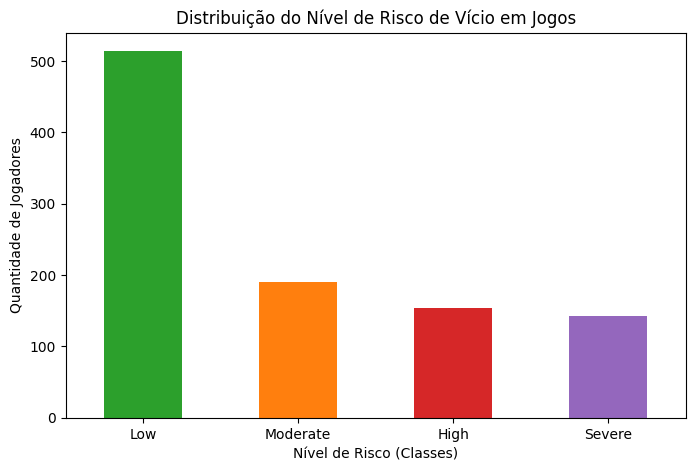

In [ ]:

# Conta as categorias e cria o gráfico de barras
df_dataset['gaming_addiction_risk_level'].value_counts().plot(
    kind='bar',
    color=['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'], # Cores diferentes para cada barra
    figsize=(8, 5) # Tamanho da imagem
)

# Adiciona título e nomes nos eixos
plt.title('Distribuição do Nível de Risco de Vício em Jogos')
plt.xlabel('Nível de Risco (Classes)')
plt.ylabel('Quantidade de Jogadores')

# Ajusta a rotação das palavras no eixo X para ficarem retas
plt.xticks(rotation=0)

# Exibe o gráfico na tela
plt.show()

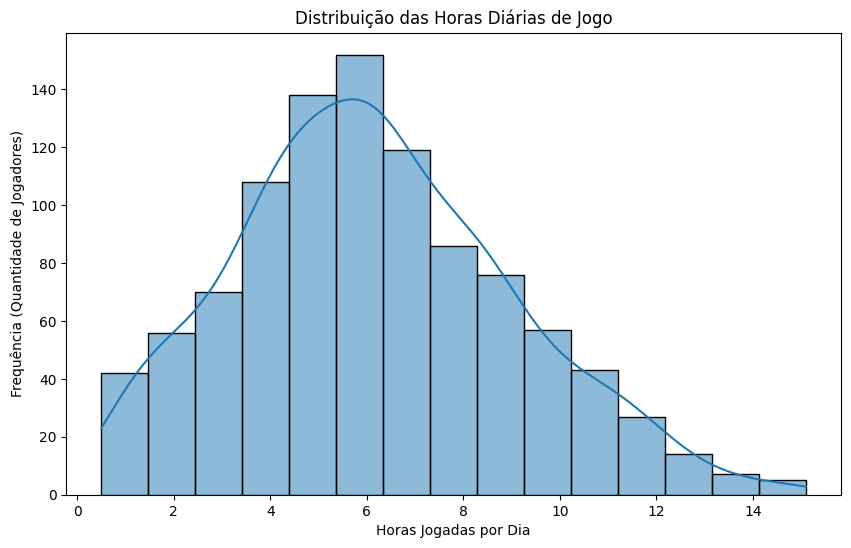

In [8]:
# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Criando o histograma com a linha de tendência (KDE)
sns.histplot(
    data=df_dataset,
    x='daily_gaming_hours',
    bins=15,
    kde=True,
    color='#1f77b4'
)

# Adicionando títulos e rótulos
plt.title('Distribuição das Horas Diárias de Jogo')
plt.xlabel('Horas Jogadas por Dia')
plt.ylabel('Frequência (Quantidade de Jogadores)')

# Exibindo o gráfico
plt.show()

# 4. Pré-processamento

Nessa etapa, realizamos os tratamentos necessários na base de dados para garantir que os modelos de aprendizado de máquina funcionem adequadamente e sem vazamento de informação.

1 - O problema encontrado foi que o atributo `record_id`, que é apenas um identificador, portanto foi removido, uma vez que os identificadores não possuem relação com a propensão ao vício em jogos.

2 -  Conforme identificado na etapa 2, os atributos `grades_gpa` e `work_productivity_score` possuem valores nulos. Para evitar perda de registros e manter a consistência dos dados, realizamos a mediana de cada atributo. Fizemos dessa forma porque se descartássemos por conta de valores nulos, perderíamos mais quase 30% da nossa base de dados.

3 - Os atributos `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems`, `eye_strain` e `back_neck_pain` estavam representados em formato True ou False, então convertemos pra formato binário de 0 e 1, já que os algoritmos precisam de representação numérica para realizar as operações algébricas nas etapas de otimização e no calculo dos pesos.

4 - Muitas variáveis do dataset são categóricas do tipo texto (object), tais como `gender`, `game_genre`, `primary_game`, `gaming_platform`, `sleep_quality`, `sleep_disruption_frequency`, `academic_work_performance`, `mood_state` e `mood_swing_frequency`. Visto isso, aplicamos a técnica de codificação One-Hot Encoding (pd.get_dummies), que cria variáveis dummy binárias para cada categoria. Aplicamos essa técnica pra corrigir a distorção causada pela transformação das categorias sem ordem hierárquica clara (tipo gêneros de jogos ou plataformas) em números ordinais (1, 2, 3), o que faria os modelos interpretarem erroneamente uma relação de grandeza numérica entre eles.

5 - As variáveis numéricas apresentam escalas totalmente distintas. Por exemplo, daily_gaming_hours varia de 0,5 a 15,1, enquanto monthly_game_spending_usd varia de 0,1 a 499,27. Por causa disso, usamos o StandardScaler para padronizar (transformando os dados para média 0 e desvio padrão 1). Modelos como os que estamos usando no projeto são muito sensíveis à escala das variáveis. Sem esse escalonamento, variáveis com magnitudes maiores (ex: gastos financeiros) dominariam os cálculos de ajuste de peso em relação às variáveis de menor magnitude (ex: horas diárias de sono).

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Cópia do dataset
df_prep = df_dataset.copy()

# Remoção de identificadores irrelevantes
if 'record_id' in df_prep.columns:
    df_prep.drop(columns=['record_id'], inplace=True)

# Conversão de booleanos para inteiros
bool_cols = df_prep.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_prep[col] = df_prep[col].astype(int)

# Separação entre X e y
X = df_prep.drop(columns=['gaming_addiction_risk_level'])
y = df_prep['gaming_addiction_risk_level']

# One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Divisão em Treino e Teste (80/20) com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Imputação pela mediana
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Escalonamento dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("--- Pré-processamento concluído ---")
print(f"Atributos gerados: {X_encoded.shape[1]}")
print(f"Amostras de Treino: {X_train_scaled.shape[0]}")
print(f"Amostras de Teste: {X_test_scaled.shape[0]}")

--- Pré-processamento concluído ---
Atributos gerados: 75
Amostras de Treino: 800
Amostras de Teste: 200


# 5. Separação dos dados

A separação entre os conjuntos de treinamento e teste foi realizada utilizando a proporção de 80% para treinamento e 20% para teste.

- Justificativa da proporção: Para um dataset de 1.000 registros, a divisão 80/20 mantém uma base de treino ampla suficiente para o modelo aprender os padrões comportamentais, e ainda reservando uma amostra estatisticamente representativa (200 registros) para a avaliação final.
- Estratificação: Foi utilizado o parâmetro `stratify=y` no momento da divisão. Isso garante que a distribuição percentual das classes do atributo-alvo (`Low`, `Moderate`, `High`, `Severe`) seja exatamente mantida tanto no conjunto de treino quanto no de teste, evitando viés de amostragem por conta do desbalanceamento.
- Reserva do conjunto de teste: O conjunto de teste foi mantido completamente isolado e reservado, sem que nenhuma informação dele interferisse no cálculo das medianas ou na padronização dos atributos.

# 6. Modelagem

1 -  **Baseline (`DummyClassifier`):**
   * *Parâmetros:* `strategy='most_frequent'`.
   * *Objetivo:* Serve como ponto de partida mínimo. Prevê sempre a classe mais frequente (`Low`) para avaliar se os modelos preditivos tão realmente aprendendo algo acima da frequência simples.
2. **`SGDClassifier`:**
   * *Parâmetros:* `loss='log_loss'` , `max_iter=1000`, `random_state=42`.
   * *Objetivo:* É um modelo linear rápido que otimiza a função de perda iterativamente, adequado para entender se o problema é linearmente separável.
3. **`RandomForestClassifier`:**
   * *Parâmetros:* `n_estimators=100`, `random_state=42`.
   * *Objetivo:* Modelo baseado em *Ensemble* (conjunto de Árvores de Decisão) que combina as previsões de múltiplas árvores para capturar relações não lineares e complexas entre as variáveis.

#### Validação cruzada:
  Para comparar os modelos de forma robusta e evitar dependência de uma única divisão de validação, utilizamos a **5-Fold Stratified Cross-Validation** sobre o conjunto de treinamento.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Definição dos modelos com os parâmetros principais
models = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent'),
    'SGDClassifier': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Configuração da Validação Cruzada Estratificada de 5 Dobras
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário para armazenar as pontuações médias da validação cruzada
cv_results = {}

print("--- Comparação de Desempenho na Validação Cruzada (Acurácia Média) ---")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (Desvio Padrão: {scores.std():.4f})")

--- Comparação de Desempenho na Validação Cruzada (Acurácia Média) ---
Baseline (Dummy): 0.5137 (Desvio Padrão: 0.0025)
SGDClassifier: 0.8112 (Desvio Padrão: 0.0334)
Random Forest: 0.9325 (Desvio Padrão: 0.0145)


#### **Comparação dos Resultados e Escolha do Modelo Final:**

* **Baseline (`DummyClassifier`):** Obteve uma eficácia média de **51,4%**, referente à previsão cega da classe mais frequente (`Low`).
* **`SGDClassifier`:** Apresentou eficácia superior ao baseline, demonstrando aprendizado, porém limitado pela fronteira de decisão ser estritamente linear.
* **`RandomForestClassifier`:** Apresentou o melhor resultado absoluto de acurácia média na validação cruzada.

Justificativa para a escolha do modelo final:
O RandomForestClassifier foi o escolhido por combinar múltiplas árvores de decisão (*Ensemble*), sendo mais capaz de mapear as interações não lineares complexas entre variáveis comportamentais e os níveis de vício em jogos.

# 7. Avaliação e discussão

Nesta etapa, avaliamos os modelos treinados utilizando o conjunto de teste inédito (200 registros), reservado na Seção 5.

Para uma avaliação completa da tarefa de classificação, analisamos as seguintes métricas do relatório de classificação:
* **Eficácia:** Proporção geral de acertos do modelo.
* **Precisão:** Capacidade de não classificar como positiva uma amostra que é negativa.
* **Recall:** Capacidade de encontrar todas as amostras positivas de uma classe.
* **F1-Score:** Média harmônica entre precisão e revocação, ideal para avaliar o desempenho em classes desbalanceadas.
* **Matriz de Confusão:** Visão gráfica dos acertos e erros de classificação por classe.


MODELO: Baseline (Dummy)
Acurácia no Teste: 0.5150
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        31
         Low       0.52      1.00      0.68       103
    Moderate       0.00      0.00      0.00        38
      Severe       0.00      0.00      0.00        28

    accuracy                           0.52       200
   macro avg       0.13      0.25      0.17       200
weighted avg       0.27      0.52      0.35       200


MODELO: SGDClassifier
Acurácia no Teste: 0.8400
              precision    recall  f1-score   support

        High       0.53      0.29      0.38        31
         Low       1.00      0.98      0.99       103
    Moderate       0.61      0.89      0.72        38
      Severe       0.92      0.86      0.89        28

    accuracy                           0.84       200
   macro avg       0.76      0.76      0.74       200
weighted avg       0.84      0.84      0.83       200


MODELO: Random Forest
Acurác

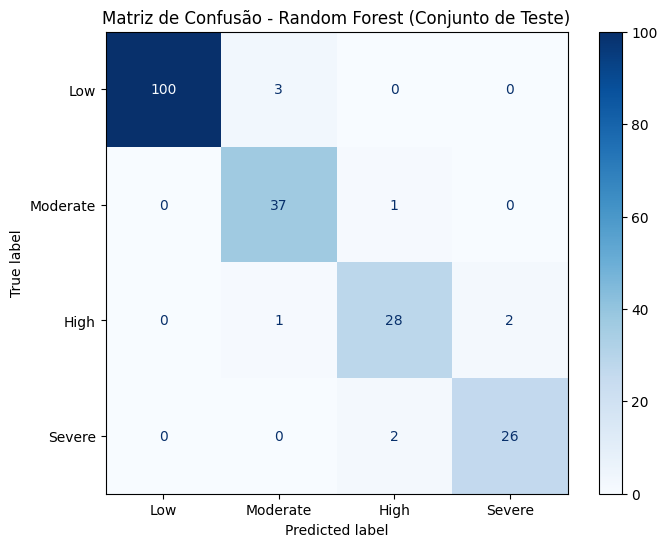

In [11]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Dicionário para armazenar as previsões no conjunto de teste
test_predictions = {}

for name, model in models.items():
    # Treinamento com o conjunto de treino completo
    model.fit(X_train_scaled, y_train)

    # Predição no conjunto de teste inédito
    y_pred = model.predict(X_test_scaled)
    test_predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)

    print(f"\n==================================================")
    print(f"MODELO: {name}")
    print(f"Acurácia no Teste: {acc:.4f}")
    print("==================================================")
    print(classification_report(y_test, y_pred, zero_division=0))

# Visualização da Matriz de Confusão do melhor modelo (Random Forest)
fig, ax = plt.subplots(figsize=(8, 6))
labels_order = ['Low', 'Moderate', 'High', 'Severe']

cm = confusion_matrix(y_test, test_predictions['Random Forest'], labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(cmap='Blues', ax=ax)

plt.title('Matriz de Confusão - Random Forest (Conjunto de Teste)')
plt.grid(False)
plt.show()

### Discussão dos Resultados, Erros e Limitações

#### 1. Qual modelo apresentou o melhor resultado e por que ele foi escolhido?**
O **RandomForestClassifier** apresentou o melhor desempenho geral em todas as métricas no conjunto de teste. Ele superou o `Baseline` e o `SGDClassifier` porque combina decisões de múltiplas árvores, conseguindo mapear interações complexas e não lineares entre padrões de sono, gastos com jogos, horas de jogo diárias e pontuações de isolamento social.

#### 2. Quais erros foram observados?
* **Predominância da classe `Low`:** Devido ao desbalanceamento original da base (51,4% dos dados pertencem à classe `Low`), o modelo apresenta métricas de precisão e recall mais elevadas nessa classe.
* **Confusão nas classes do meio:** Ao analisar a matriz de confusão, observa-se que os erros de classificação ocorrem majoritariamente entre faixas de risco vizinhas (por exemplo, classificar um jogador de risco `Moderate` como `Low` ou `High`). O modelo raramente cometeu erros extremos (como confundir `Low` com `Severe`).

#### 3. Quais limitações existem?
* **Desbalanceamento de Classes:** O menor volume de amostras nas classes de maior risco (`High` e `Severe`) limita o aprendizado do modelo nessas categorias específicas.
* **Tamanho do Dataset:** Por contar com 1.000 registros, a amostra de teste possui 200 dados, o que torna as métricas sensíveis a pequenas variações nas previsões das classes minoritárias.

#### 4. O que poderia ser melhorado?
* **Técnicas de Reamostragem:** Aplicação de algoritmos como **SMOTE** (*Synthetic Minority Over-sampling Technique*) no conjunto de treinamento para sintetizar amostras das classes `Moderate`, `High` e `Severe`.
* **Otimização de Hiperparâmetros:** Utilização de `GridSearchCV` ou `RandomizedSearchCV` para buscar hiperparâmetros ótimos (ex: profundidade máxima das árvores, número de estimadores, critérios de divisão).